# **Cellule 1 — Imports**

In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# **Cellule 2 — device**

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


# **Cellule 3 — Chargement du dataset**

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("\nClasses :", np.unique(y))
print("\nAperçu des données :")
display(X.head())

print("\nValeurs manquantes :")
print(X.isnull().sum().sum())

Shape X : (569, 30)
Shape y : (569,)

Classes : [0 1]

Aperçu des données :


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Valeurs manquantes :
0


c’est un problème de classification binaire sur données tabulaires réelles.



# **Cellule 4 — Split train / validation / test**

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)
# ~ 70% train, 15% val, 15% test

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (397, 30) (397,)
Val   : (86, 30) (86,)
Test  : (86, 30) (86,)


# **Cellule 5 — Normalisation**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Moyenne train après normalisation (approx) :", X_train_scaled.mean())
print("Écart-type train après normalisation (approx) :", X_train_scaled.std())

Moyenne train après normalisation (approx) : 2.780125229758243e-16
Écart-type train après normalisation (approx) : 1.0


# **Cellule 6 — Conversion en tenseurs + DataLoaders**

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Nombre de batches train :", len(train_loader))
print("Nombre de batches val   :", len(val_loader))
print("Nombre de batches test  :", len(test_loader))

Nombre de batches train : 13
Nombre de batches val   : 3
Nombre de batches test  : 3


# **Cellule 7 — MLP version 1 : nn.Sequential**

In [ ]:
input_dim = X_train_tensor.shape[1]

mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

print(mlp_sequential)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


# **Cellule 8 — MLP version 2 : classe personnalisée**

In [ ]:
class CustomMLP(nn.Module):
    def __init__(self, input_dim):
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

mlp_custom = CustomMLP(input_dim)
print(mlp_custom)

CustomMLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


# **Cellule 9 — Inspection des paramètres**

In [ ]:
print("=== named_parameters() ===")
for name, param in mlp_custom.named_parameters():
    print(f"{name} | shape={tuple(param.shape)} | requires_grad={param.requires_grad}")

print("\n=== state_dict() keys ===")
for key in mlp_custom.state_dict().keys():
    print(key)

=== named_parameters() ===
fc1.weight | shape=(64, 30) | requires_grad=True
fc1.bias | shape=(64,) | requires_grad=True
fc2.weight | shape=(32, 64) | requires_grad=True
fc2.bias | shape=(32,) | requires_grad=True
fc3.weight | shape=(1, 32) | requires_grad=True
fc3.bias | shape=(1,) | requires_grad=True

=== state_dict() keys ===
fc1.weight
fc1.bias
fc2.weight
fc2.bias
fc3.weight
fc3.bias


# **Cellule 10 — Fonctions d’initialisation**

In [ ]:
def init_weights_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        nn.init.constant_(m.bias, 0.0)

def init_weights_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.01)
        nn.init.constant_(m.bias, 0.0)

def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.constant_(m.bias, 0.0)

# **Cellule 11 — Fonction d’évaluation**

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(y_batch.cpu().numpy().flatten())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds)
    rec = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": all_targets,
        "y_pred": all_preds,
        "y_prob": all_probs
    }

# **Cellule 12 — Fonction d’entraînement**

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_running_loss += loss.item() * X_batch.size(0)

        val_loss = val_running_loss / len(val_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_metrics["f1"])

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history, best_f1

# **Cellule 13 — Fonction pour lancer une expérience**

In [ ]:
def run_experiment(model_type="sequential", init_type="xavier", epochs=50, lr=0.001):
    if model_type == "sequential":
        model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    elif model_type == "custom":
        model = CustomMLP(input_dim)
    else:
        raise ValueError("model_type doit être 'sequential' ou 'custom'")

    if init_type == "normal":
        model.apply(init_weights_normal)
    elif init_type == "constant":
        model.apply(init_weights_constant)
    elif init_type == "xavier":
        model.apply(init_weights_xavier)
    else:
        raise ValueError("init_type doit être 'normal', 'constant' ou 'xavier'")

    trained_model, history, best_f1 = train_model(
        model, train_loader, val_loader, device, epochs=epochs, lr=lr
    )

    test_metrics = evaluate_model(trained_model, test_loader, device)

    result = {
        "model_type": model_type,
        "init_type": init_type,
        "best_val_f1": best_f1,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "confusion_matrix": test_metrics["confusion_matrix"],
        "history": history,
        "model": trained_model
    }

    return result

# **Cellule 14 — Lancer les expériences demandées**

In [ ]:
results = []

experiments = [
    ("sequential", "normal"),
    ("sequential", "constant"),
    ("sequential", "xavier"),
    ("custom", "normal"),
    ("custom", "constant"),
    ("custom", "xavier"),
]

for model_type, init_type in experiments:
    print(f"\n==============================")
    print(f"Modèle: {model_type} | Init: {init_type}")
    print(f"==============================")

    result = run_experiment(model_type=model_type, init_type=init_type, epochs=50, lr=0.001)
    results.append(result)


Modèle: sequential | Init: normal
Epoch [1/50] | Train Loss: 0.6882 | Val Loss: 0.6758 | Val F1: 0.9730
Epoch [2/50] | Train Loss: 0.6484 | Val Loss: 0.5951 | Val F1: 0.9818
Epoch [3/50] | Train Loss: 0.5237 | Val Loss: 0.4024 | Val F1: 0.9725
Epoch [4/50] | Train Loss: 0.3228 | Val Loss: 0.1974 | Val F1: 0.9725
Epoch [5/50] | Train Loss: 0.1906 | Val Loss: 0.1013 | Val F1: 0.9815
Epoch [6/50] | Train Loss: 0.1314 | Val Loss: 0.0638 | Val F1: 0.9907
Epoch [7/50] | Train Loss: 0.1041 | Val Loss: 0.0460 | Val F1: 1.0000
Epoch [8/50] | Train Loss: 0.0892 | Val Loss: 0.0362 | Val F1: 1.0000
Epoch [9/50] | Train Loss: 0.0792 | Val Loss: 0.0309 | Val F1: 1.0000
Epoch [10/50] | Train Loss: 0.0730 | Val Loss: 0.0267 | Val F1: 1.0000
Epoch [11/50] | Train Loss: 0.0693 | Val Loss: 0.0259 | Val F1: 1.0000
Epoch [12/50] | Train Loss: 0.0641 | Val Loss: 0.0227 | Val F1: 1.0000
Epoch [13/50] | Train Loss: 0.0605 | Val Loss: 0.0201 | Val F1: 1.0000
Epoch [14/50] | Train Loss: 0.0573 | Val Loss: 0.01

# **Cellule 15 — Tableau récapitulatif**

In [ ]:
results_df = pd.DataFrame([
    {
        "model_type": r["model_type"],
        "init_type": r["init_type"],
        "best_val_f1": r["best_val_f1"],
        "test_accuracy": r["test_accuracy"],
        "test_precision": r["test_precision"],
        "test_recall": r["test_recall"],
        "test_f1": r["test_f1"]
    }
    for r in results
])

results_df = results_df.sort_values(by="test_f1", ascending=False).reset_index(drop=True)
display(results_df)

,model_type,init_type,best_val_f1,test_accuracy,test_precision,test_recall,test_f1
0,sequential,xavier,1.000000,0.965116,0.963636,0.981481,0.972477
1,custom,xavier,1.000000,0.941860,0.962264,0.944444,0.953271
2,sequential,normal,1.000000,0.930233,0.961538,0.925926,0.943396
3,custom,normal,1.000000,0.930233,0.980000,0.907407,0.942308
4,sequential,constant,0.771429,0.627907,0.627907,1.000000,0.771429
5,custom,constant,0.771429,0.627907,0.627907,1.000000,0.771429


# **Cellule 16 — Courbes d’apprentissage du meilleur modèle**

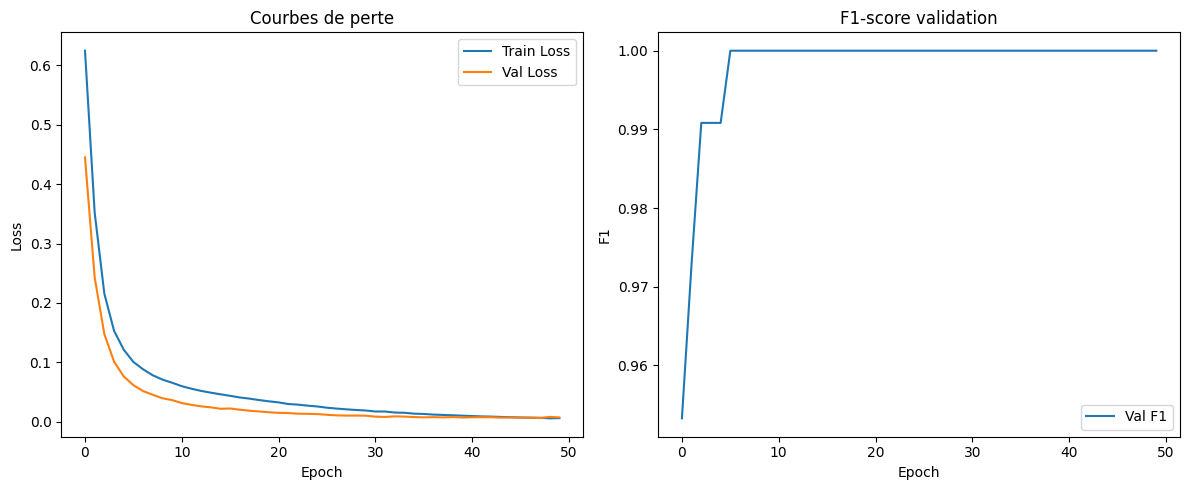

In [ ]:
best_idx = results_df["test_f1"].idxmax()
best_model_type = results_df.loc[best_idx, "model_type"]
best_init_type = results_df.loc[best_idx, "init_type"]

best_result = None
for r in results:
    if r["model_type"] == best_model_type and r["init_type"] == best_init_type:
        best_result = r
        break

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_result["history"]["train_loss"], label="Train Loss")
plt.plot(best_result["history"]["val_loss"], label="Val Loss")
plt.title("Courbes de perte")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_result["history"]["val_f1"], label="Val F1")
plt.title("F1-score validation")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()

plt.tight_layout()
plt.show()

# **Cellule 17 — Matrice de confusion du meilleur modèle**

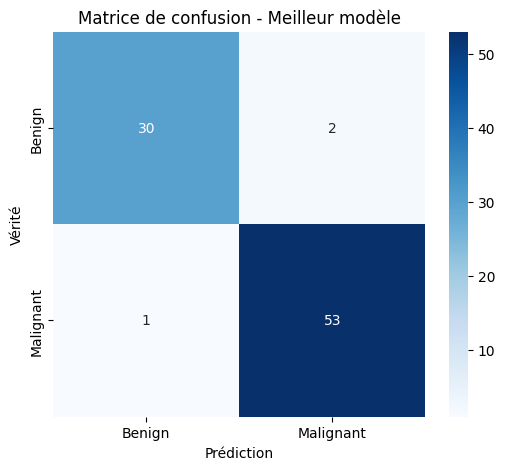

In [ ]:
cm = best_result["confusion_matrix"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.title("Matrice de confusion - Meilleur modèle")
plt.show()

# **Cellule 18 — Rapport de classification**

In [ ]:
best_model = best_result["model"]
best_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = best_model(X_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(y_batch.cpu().numpy().flatten())

print(classification_report(all_targets, all_preds, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.97      0.94      0.95        32
   Malignant       0.96      0.98      0.97        54

    accuracy                           0.97        86
   macro avg       0.97      0.96      0.96        86
weighted avg       0.97      0.97      0.96        86



# **Cellule 19 — Sauvegarde du meilleur modèle**

In [ ]:
os.makedirs("models", exist_ok=True)

best_model_path = "models/best_mlp_model.pt"
torch.save(best_model.state_dict(), best_model_path)

print("Meilleur modèle sauvegardé dans :", best_model_path)

Meilleur modèle sauvegardé dans : models/best_mlp_model.pt


# **Cellule 20 — Rechargement du meilleur modèle**

In [ ]:
reloaded_model = CustomMLP(input_dim) if best_result["model_type"] == "custom" else nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

reloaded_model.load_state_dict(torch.load(best_model_path, map_location=device))
reloaded_model = reloaded_model.to(device)

reloaded_metrics = evaluate_model(reloaded_model, test_loader, device)

print("Accuracy après rechargement :", reloaded_metrics["accuracy"])
print("Precision après rechargement:", reloaded_metrics["precision"])
print("Recall après rechargement   :", reloaded_metrics["recall"])
print("F1 après rechargement       :", reloaded_metrics["f1"])

Accuracy après rechargement : 0.9651162790697675
Precision après rechargement: 0.9636363636363636
Recall après rechargement   : 0.9814814814814815
F1 après rechargement       : 0.9724770642201835
